<a href="https://colab.research.google.com/github/arshathvarunsha/2DAbsorptionTiltedLattice/blob/master/RELAXATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import numpy as np
import matplotlib.pylab as plt


In [68]:
class parameters():
  amu, ps, cm, Å =  1836.0, 41341.37, 1/0.000004556, 1.8897259885789
  c, π = 137.036, np.pi
  c = c/2.4
  eV = 1/27.2114
  Nsite = 10
  Nlayer = 1
  τ = 4 * 100/cm
  β = 1052.8# a.u. is 300K is 1052.8
  ω = 720/cm
  γ =  5 * ((ω)**1.5)
  a = 12 * Å
  ϵ0 = 2.8 * eV
  Lz = 1000 * Å # 0.01 * Nsite * a * Å
  kz = (np.pi/Lz)
  Rn = np.arange(Nsite)
  ke =  2 * π * (Rn)/(Nsite*a) # Kpoints
  ω0 = c*kz
  ωk = np.roll( c * np.sqrt((ke - ke[Nsite//2])**2 + (kz)**2), -1 * (Nsite//2))
  εk = ϵ0 * np.ones(Nsite) -2*τ*np.cos((ke)*a)
  g  = 2.6 * 1500/cm
# ωk = parameters.ωk
# εk = parameters.εk
# ke = parameters.ke
# plt.plot(ke*parameters.a, ωk/parameters.eV)
# plt.plot(ke*parameters.a, εk/parameters.eV)
# #plt.xlim(0, np.pi/10)
# plt.ylim(0,5)

def initR():
    #np.random.seed(seednum)

    β  = parameters.β
    ω  = parameters.ω

    N = parameters.Nsite
    Nlayer = parameters.Nlayer

    sigP = np.sqrt( ω / ( 2 * np.tanh( 0.5*β*ω ) ) )
    sigR = sigP/ω

    Rd = np.zeros((Nlayer * N))
    Pd = np.zeros((Nlayer * N))
    for d in range(Nlayer * N):
        Rd[d] = np.random.normal()*sigR
        Pd[d] = np.random.normal()*sigP
    #print("Rd: ", np.round(Rd[:20],3))
    return Rd , Pd

In [69]:
ωk = parameters.ωk
εk = parameters.εk
ke = parameters.ke

def H2x2(kindex):
  ωkindex = parameters.ωk[kindex]
  εkindex = parameters.εk[kindex]
  g = parameters.g
  h = np.zeros((2,2), dtype=complex)
  h[0,0] = εkindex
  h[1,1] = ωkindex
  h[0,1], h[1,0] = g, g
  Ekindex, Vkindex = np.linalg.eigh(h)
  return Ekindex, Vkindex

Eup = np.zeros(parameters.Nsite)
Vup = np.zeros((2, parameters.Nsite), dtype=complex)
Elow = np.zeros(parameters.Nsite)
Vlow = np.zeros((2, parameters.Nsite), dtype=complex)
for kindex in range(parameters.Nsite):
  Ekindex, Vkindex = H2x2(kindex)
  Eup[kindex] = Ekindex[0]
  Vup[:,kindex] = Vkindex[:,0]
  Elow[kindex] = Ekindex[1]
  Vlow[:,kindex] = Vkindex[:,1]

Ek = np.sort(np.concatenate((Eup, Elow)))
# plt.plot((ke - ke[parameters.Nsite//2])*parameters.a, np.roll(Eup/parameters.eV, -(parameters.Nsite//2)))
# plt.plot((ke - ke[parameters.Nsite//2])*parameters.a, np.roll(Elow/parameters.eV, -(parameters.Nsite//2)))

# plt.xlim(-(np.pi/30), np.pi/30)
# plt.ylim(0, 5)


In [70]:
myRn, myPn = initR()
#print("mean of Rn", np.mean(myRn))

def Hrl(Rn):
  Nsite = parameters.Nsite
  ke = parameters.ke
  ωk = parameters.ωk
  ϵ0 = parameters.ϵ0
  τ = parameters.τ
  g = parameters.g
  a = parameters.a
  γ = parameters.γ


  Hreal = np.zeros((2*Nsite, 2*Nsite), dtype=complex)
  # bare exciton
  Hexc = np.zeros((Nsite, Nsite))
  Hexc += ϵ0 * np.eye(Nsite) + γ * np.diag(Rn)
  Hexc += -τ * np.eye(Nsite, k=1)
  Hexc += -τ * np.eye(Nsite, k=-1)
  Hexc[0,-1], Hexc[-1,0] = -τ, -τ

  Hreal[:Nsite, :Nsite] = Hexc[:]

  # bare cavity
  Hreal[Nsite:, Nsite:] = np.diag(ωk)

  # exciton-photon coupling
  kdotR = np.outer(ke*a, np.arange(Nsite))

  Hreal[Nsite:, :Nsite] += (g/np.sqrt(Nsite)) * np.exp(-1.j*kdotR)
  Hreal[:Nsite, Nsite:] += (g/np.sqrt(Nsite)) * np.exp(1.j*kdotR)

  # print("Hreal = \n", np.round(Hreal,4))

  return Hreal


Ereal, Vreal = np.linalg.eigh(Hrl(myRn))

print("Ek - Ereal = ", np.max(np.abs(Ereal - Ek)))

# print("Ek = ", Ek)
# print("Ereal = ", Ereal)
# print("ωk = ", parameters.ωk)


Ek - Ereal =  0.015106396191800112


vu normalization =  1.0000000000000002
vu normalization =  1.0
vu normalization =  0.9999999999999999
vu normalization =  0.9999999999999999
vu normalization =  1.0000000000000002
vu normalization =  1.0000000000000002
vu normalization =  1.0000000000000002
vu normalization =  0.9999999999999999
vu normalization =  0.9999999999999999
vu normalization =  1.0
transmatrix = 
 [[0.0819 0.0024 0.0013 0.0025 0.0012 0.0021 0.0012 0.0025 0.0013 0.0024]
 [0.0024 0.1059 0.0037 0.002  0.0037 0.0018 0.0032 0.0018 0.0037 0.002 ]
 [0.0013 0.0037 0.1079 0.0037 0.002  0.0037 0.0018 0.0032 0.0018 0.0037]
 [0.0025 0.002  0.0037 0.1102 0.0037 0.002  0.0037 0.0018 0.0032 0.0018]
 [0.0012 0.0037 0.002  0.0037 0.112  0.0037 0.002  0.0037 0.0018 0.0032]
 [0.0021 0.0018 0.0037 0.002  0.0037 0.1127 0.0037 0.002  0.0037 0.0018]
 [0.0012 0.0032 0.0018 0.0037 0.002  0.0037 0.112  0.0037 0.002  0.0037]
 [0.0025 0.0018 0.0032 0.0018 0.0037 0.002  0.0037 0.1102 0.0037 0.002 ]
 [0.0013 0.0037 0.0018 0.0032 0.0018 0.0

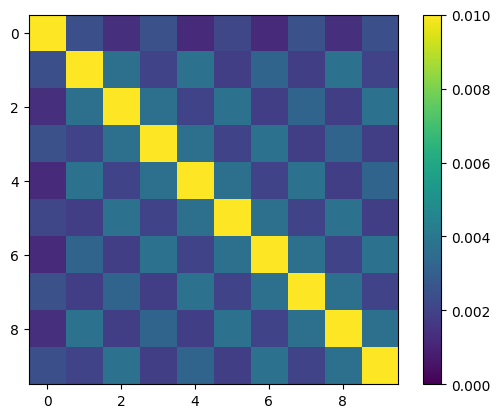

In [71]:
Nsite = parameters.Nsite
Hreal = Hrl(myRn)
transmatrix = np.zeros((Nsite, Nsite))
for i in np.arange(Nsite):
  print("vu normalization = ", np.sum(np.abs(Vup[:, i])**2))
  psi_plus_k = np.zeros(2*Nsite, dtype = complex)
  psi_plus_k[i] = Vup[0, i]
  psi_plus_k[Nsite + i] = Vup[1, i]
  psi_plus_real = np.zeros(2*Nsite, dtype = complex)
  psi_plus_real[Nsite + i] = Vup[1, i]
  #psi_plus_real[:Nsite] = Vup[0, i] * np.exp(-1.j*(2*np.pi/Nsite)*i*np.arange(Nsite))/np.sqrt(Nsite)
  psi_plus_real[:Nsite] = np.fft.ifft(psi_plus_k[:Nsite], norm='ortho')
  for j in np.arange(Nsite):
      psi_minus_k = np.zeros(2*Nsite, dtype = complex)
      psi_minus_k[j] = Vup[0, j]
      psi_minus_k[Nsite + j] = Vup[1, j]
      psi_minus_real = np.zeros(2*Nsite, dtype = complex)
      psi_minus_real[Nsite + j] = Vup[1, j]
      #psi_minus_real[:Nsite] = Vup[0, j] * np.exp(-1.j*(2*np.pi/Nsite)*j*np.arange(Nsite))/np.sqrt(Nsite)
      psi_minus_real[:Nsite] = np.fft.ifft(psi_minus_k[:Nsite], norm='ortho')
      transmatrix[i,j] = np.abs(np.conj(psi_minus_real) @ Hreal @ psi_plus_real)

print("transmatrix = \n", np.round(transmatrix,4))
plt.imshow(transmatrix)
plt.colorbar()
plt.clim(0, 0.01)
plt.show()


Analytical method